# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV961"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv961')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv961/lv961-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV961,gene_band
0,LIM2,7.833942,19q13.41
1,CRYBB1,7.500986,22q12.1
2,BFSP1,1.855240,20p12.1
3,GJA3,1.608983,13q12.11
4,WLS,1.117509,1p31.3
5,COLEC12,0.861610,18p11.32
6,SLC4A5,0.842080,2p13.1
7,WNT1,0.737528,12q13.12
8,AANAT,0.682152,17q25.1
9,FGFR2,0.663595,10q26.13


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-26 17:28:27,364 - numexpr.utils] INFO: Note: NumExpr detected 48 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-26 17:28:27,365 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP055513, SRP041179, SRP015336, SRP055810, SRP050499, SRP055569, SRP066834, SRP011546, SRP042161, SRP064259, SRP057156, SRP030617, SRP033135, SRP002326, SRP041819, SRP018020, SRP055153, SRP049203, SRP057196, SRP047194, SRP022920, SRP014213, SRP002079, SRP018848, SRP019994, SRP049820, SRP033464, SRP048761, SRP049449, SRP009266, SRP034528, SRP017199, SRP051472, SRP008145, SRP050992, SRP026537, SRP012099, SRP017777, SRP028180, SRP017966, SRP029281, SRP014670, SRP060416, SRP012695, SRP045876, SRP041833, SRP036821, SRP039348, SRP011895, SRP059692, SRP033267, SRP057205, SRP012098, SRP051765, SRP046254, SRP053366, SRP068078, SRP059379, SRP035862, SRP061682, SRP064464, SRP059035, SRP016140, SRP051772, SRP049981, SRP067701, SRP042186, SRP022892, SRP002487, SRP042153, SRP009862, SRP049553, SRP040243, SRP057147, SRP018838, SRP027383, SRP043960, SRP042620, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (76 != 78)
  warnings.warn(


In [12]:
lv_data.shape

(7192, 119)

In [13]:
lv_data.head()

tissue gestational age trimester     Sex Stage  \
project   run                                                           
SRP055513 SRR1818497   spleen              16         2    Male   NaN   
          SRR1818600  stomach              22         2    Male   NaN   
          SRR1818599     cord             9.3         1    Male   NaN   
          SRR1818598     lung              22         2    Male   NaN   
          SRR1818597    gonad             9.4         1  Female   NaN   

                     cell type run id disease status developmental stage  \
project   run                                                              
SRP055513 SRR1818497       NaN    NaN            NaN                 NaN   
          SRR1818600       NaN    NaN            NaN                 NaN   
          SRR1818599       NaN    NaN            NaN                 NaN   
          SRR1818598       NaN    NaN            NaN                 NaN   
          SRR1818597       NaN    NaN            NaN                 NaN   

                     lineage  ... antibody catalog #  \
project   run                 ...                      
SRP055513 SRR1818497     NaN  ...                NaN   
          SRR1818600     NaN  ...                NaN   
          SRR1818599     NaN  ...                NaN   
          SRR1818598     NaN  ...                NaN   
          SRR1818597     NaN  ...                NaN   

                     immunoprecipitated protein weight of protein recovered  \
project   run                                                                 
SRP055513 SRR1818497                        NaN                         NaN   
          SRR1818600                        NaN                         NaN   
          SRR1818599                        NaN                         NaN   
          SRR1818598                        NaN                         NaN   
          SRR1818597                        NaN                         NaN   

                     passage number sirna knockdown molecule subtype labexpid  \
project   run                                                                   
SRP055513 SRR1818497            NaN             NaN              NaN      NaN   
          SRR1818600            NaN             NaN              NaN      NaN   
          SRR1818599            NaN             NaN              NaN      NaN   
          SRR1818598            NaN             NaN              NaN      NaN   
          SRR1818597            NaN             NaN              NaN      NaN   

                     history induction     LV961  
project   run                                     
SRP055513 SRR1818497     NaN       NaN -0.020538  
          SRR1818600     NaN       NaN  0.025434  
          SRR1818599     NaN       NaN  0.016353  
          SRR1818598     NaN       NaN  0.059153  
          SRR1818597     NaN       NaN -0.002873  

[5 rows x 119 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

disease status         0.531498
run id                 0.342820
gestational age        0.323029
trimester              0.323029
Sex                    0.323029
Stage                  0.026300
lineage                0.025601
embryo number          0.025601
tissue                 0.020101
cell type              0.006176
clone                  0.005800
developmental stage    0.004958
phenotype              0.004586
passage                0.001865
facs                   0.001691
agent                  0.001648
gender                 0.001626
fertility status       0.001623
antibodies             0.001488
sequencing library     0.001381
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
_tmp2 = lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)
display(_tmp2)

tissue            0.020101
cell type         0.006176
cell line         0.000713
tissue subtype    0.000176
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = _tmp2.index.tolist()
display(lv_attrs_selected)

['tissue', 'cell type', 'cell line', 'tissue subtype']

In [17]:
# lv_attrs_selected = [
#     "cell type",
#     "tissue",
#     "tissue subtype",
#     "cell line",
# ]

In [18]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [19]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [20]:
_tmp_seq[0]

tissue     cell type cell line tissue subtype     LV961
project   run                                                                
SRP055513 SRR1818536     eye           NaN       NaN            NaN  5.977150
SRP041179 SRR1238513     NaN  hESC (WA-09)       NaN            NaN  2.316134
          SRR1238516     NaN  hESC (WA-09)       NaN            NaN  2.138090
          SRR1238514     NaN  hESC (WA-09)       NaN            NaN  1.703400
          SRR1238534     NaN  hESC (WA-09)       NaN            NaN  1.583302
SRP015336 SRR548611   retina           NaN       NaN            NaN  1.438201
SRP041179 SRR1238515     NaN  hESC (WA-09)       NaN            NaN  1.404468
          SRR1238511     NaN  hESC (WA-09)       NaN            NaN  1.388254
          SRR1238512     NaN  hESC (WA-09)       NaN            NaN  1.253697
          SRR1238535     NaN  hESC (WA-09)       NaN            NaN  1.181283
          SRR1238531     NaN  hESC (WA-09)       NaN            NaN  0.803514
          SRR1238532     NaN  hESC (WA-09)       NaN            NaN  0.641269
SRP055810 SRR2240634     NaN           NaN       NaN            NaN  0.568066
          SRR2240633     NaN           NaN       NaN            NaN  0.544098
SRP041179 SRR1238510     NaN  hESC (WA-09)       NaN            NaN  0.537548
SRP055810 SRR2240637     NaN           NaN       NaN            NaN  0.512201
SRP041179 SRR1238509     NaN  hESC (WA-09)       NaN            NaN  0.507191
SRP055810 SRR2240635     NaN           NaN       NaN            NaN  0.502985
          SRR2240636     NaN           NaN       NaN            NaN  0.499477
SRP041179 SRR1238536     NaN  hESC (WA-09)       NaN            NaN  0.475751
          SRR1238522     NaN  hESC (WA-09)       NaN            NaN  0.458888
SRP055810 SRR2240642     NaN           NaN       NaN            NaN  0.458827
SRP041179 SRR1238521     NaN  hESC (WA-09)       NaN            NaN  0.451318
SRP055513 SRR1818490     eye           NaN       NaN            NaN  0.449303
SRP015336 SRR548612   retina           NaN       NaN            NaN  0.427674

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [21]:
_tmp_seq[1]

tissue  \
project   run                                               
SRP055810 SRR2240641                                  NaN   
          SRR2240639                                  NaN   
          SRR2240638                                  NaN   
          SRR2240640                                  NaN   
SRP041179 SRR1238533                                  NaN   
SRP050499 SRR2013635                                  NaN   
SRP055569 SRR2019147                                  NaN   
SRP041179 SRR1238525                                  NaN   
SRP066834 SRR2967275  Dissociated whole cerebral organoid   
SRP041179 SRR1238530                                  NaN   
          SRR1238526                                  NaN   
          SRR1238528                                  NaN   
SRP066834 SRR2967249  Dissociated whole cerebral organoid   
SRP041179 SRR1238507                                  NaN   
          SRR1238524                                  NaN   
          SRR1238523                                  NaN   
          SRR1238527                                  NaN   
          SRR1238504                                  NaN   
          SRR1238503                                  NaN   
SRP011546 SRR491035         human preimplantation embryos   
SRP042161 SRR1294679                                  NaN   
SRP050499 SRR2013638                                  NaN   
SRP041179 SRR1238508                                  NaN   
SRP050499 SRR2013639                                  NaN   
SRP066834 SRR2967371  Dissociated whole cerebral organoid   

                                                              cell type  \
project   run                                                             
SRP055810 SRR2240641                                                NaN   
          SRR2240639                                                NaN   
          SRR2240638                                                NaN   
          SRR2240640                                                NaN   
SRP041179 SRR1238533                                       hESC (WA-09)   
SRP050499 SRR2013635                                                NaN   
SRP055569 SRR2019147  mixture of U87 human glioma cells and WI-38 hu...   
SRP041179 SRR1238525                                       hESC (WA-09)   
SRP066834 SRR2967275                                                NaN   
SRP041179 SRR1238530                                       hESC (WA-09)   
          SRR1238526                                       hESC (WA-09)   
          SRR1238528                                       hESC (WA-09)   
SRP066834 SRR2967249                                                NaN   
SRP041179 SRR1238507                                       hESC (WA-09)   
          SRR1238524                                       hESC (WA-09)   
          SRR1238523                                       hESC (WA-09)   
          SRR1238527                                       hESC (WA-09)   
          SRR1238504                                       hESC (WA-09)   
          SRR1238503                                       hESC (WA-09)   
SRP011546 SRR491035                    human preimplantation blastomere   
SRP042161 SRR1294679                                       Glioblastoma   
SRP050499 SRR2013638                                                NaN   
SRP041179 SRR1238508                                       hESC (WA-09)   
SRP050499 SRR2013639                                                NaN   
SRP066834 SRR2967371                                                NaN   

                     cell line tissue subtype     LV961  
project   run                                            
SRP055810 SRR2240641       NaN            NaN  0.419483  
          SRR2240639       NaN            NaN  0.411242  
          SRR2240638       NaN            NaN  0.405685  
          SRR2240640       NaN            NaN  0.403060  
SRP041179 SRR1238533       Na

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [22]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = lv_attrs_selected

In [24]:
# SELECTED_ATTRIBUTES = [
#     "cell type",
#     "tissue",
#     "tissue subtype",
#     "cell line",
# ]

In [25]:
display(SELECTED_ATTRIBUTES)

['tissue', 'cell type', 'cell line', 'tissue subtype']

## Get a single attribute with "cell type/tissue" information

In [26]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [27]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [28]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [29]:
plot_data.head(20)

tissue     LV961
project   run                                  
SRP055513 SRR1818536              eye  5.977150
SRP041179 SRR1238513     hESC (WA-09)  2.316134
          SRR1238516     hESC (WA-09)  2.138090
          SRR1238514     hESC (WA-09)  1.703400
          SRR1238534     hESC (WA-09)  1.583302
SRP015336 SRR548611            retina  1.438201
SRP041179 SRR1238515     hESC (WA-09)  1.404468
          SRR1238511     hESC (WA-09)  1.388254
          SRR1238512     hESC (WA-09)  1.253697
          SRR1238535     hESC (WA-09)  1.181283
          SRR1238531     hESC (WA-09)  0.803514
          SRR1238532     hESC (WA-09)  0.641269
SRP055810 SRR2240634  NOT CATEGORIZED  0.568066
          SRR2240633  NOT CATEGORIZED  0.544098
SRP041179 SRR1238510     hESC (WA-09)  0.537548
SRP055810 SRR2240637  NOT CATEGORIZED  0.512201
SRP041179 SRR1238509     hESC (WA-09)  0.507191
SRP055810 SRR2240635  NOT CATEGORIZED  0.502985
          SRR2240636  NOT CATEGORIZED  0.499477
SRP041179 SRR1238536     hESC (WA-09)  0.475751

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [30]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [31]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [32]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [33]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [34]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [35]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [36]:
N_TOP_ATTRS = 10

In [37]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [38]:
len(attr_order)

10

In [39]:
attr_order[:5]

['eye',
 'hESC (WA-09)',
 'retina',
 'NOT CATEGORIZED',
 'mixture of U87 human glioma cells and WI-38 human lung fibroblast cells']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

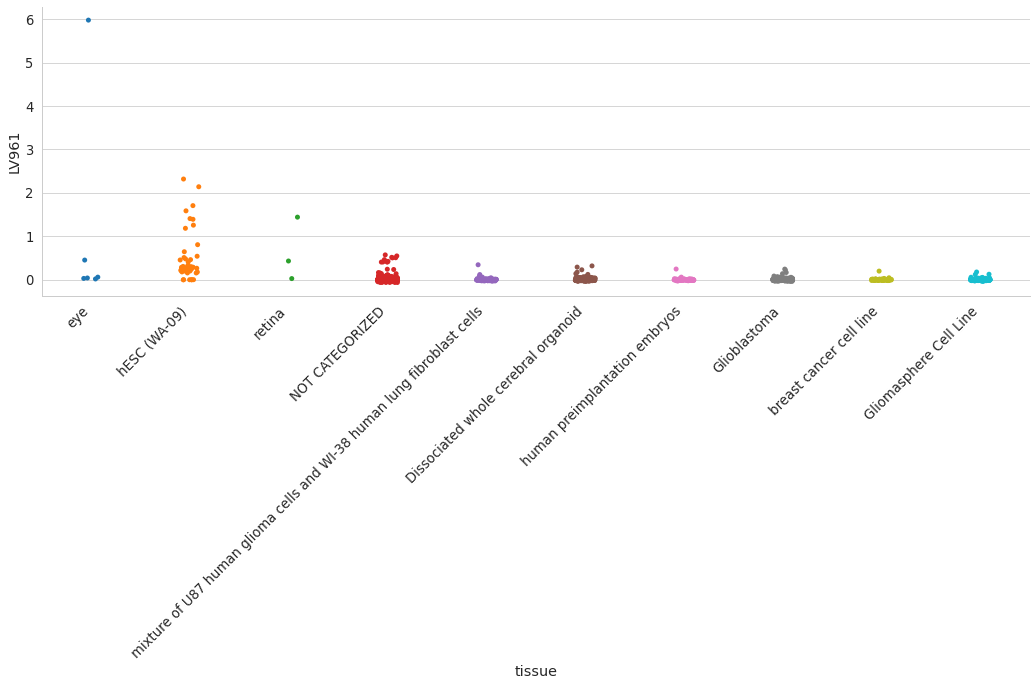

In [40]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [43]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("hESC")
    ]
    display(_tmp.head(20))

tissue     LV961
project   run                               
SRP041179 SRR1238513  hESC (WA-09)  2.316134
          SRR1238516  hESC (WA-09)  2.138090
          SRR1238514  hESC (WA-09)  1.703400
          SRR1238534  hESC (WA-09)  1.583302
          SRR1238515  hESC (WA-09)  1.404468
          SRR1238511  hESC (WA-09)  1.388254
          SRR1238512  hESC (WA-09)  1.253697
          SRR1238535  hESC (WA-09)  1.181283
          SRR1238531  hESC (WA-09)  0.803514
          SRR1238532  hESC (WA-09)  0.641269
          SRR1238510  hESC (WA-09)  0.537548
          SRR1238509  hESC (WA-09)  0.507191
          SRR1238536  hESC (WA-09)  0.475751
          SRR1238522  hESC (WA-09)  0.458888
          SRR1238521  hESC (WA-09)  0.451318
          SRR1238533  hESC (WA-09)  0.402691
          SRR1238525  hESC (WA-09)  0.320126
          SRR1238530  hESC (WA-09)  0.305123
          SRR1238526  hESC (WA-09)  0.302768
          SRR1238528  hESC (WA-09)  0.298695

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP041179, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [44]:
# what is there in these projects?
lv_data.loc[["SRP041179"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

Stage     cell type     run id  \
project   run                                                           
SRP041179 SRR1238513   Upper Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238516   Upper Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238514   Upper Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238534                     NaN  hESC (WA-09)  Test Case   
          SRR1238515   Upper Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238511    Deep Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238512    Deep Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238535                     NaN  hESC (WA-09)  Test Case   
          SRR1238531                     NaN  hESC (WA-09)  Test Case   
          SRR1238532                     NaN  hESC (WA-09)  Test Case   
          SRR1238510    Deep Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238509    Deep Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238536                     NaN  hESC (WA-09)  Test Case   
          SRR1238522                     NaN  hESC (WA-09)  Test Case   
          SRR1238521                     NaN  hESC (WA-09)  Test Case   
          SRR1238533                     NaN  hESC (WA-09)  Test Case   
          SRR1238525                     NaN  hESC (WA-09)  Test Case   
          SRR1238530                     NaN  hESC (WA-09)  Test Case   
          SRR1238526                     NaN  hESC (WA-09)  Test Case   
          SRR1238528                     NaN  hESC (WA-09)  Test Case   
          SRR1238507    Deep Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238524                     NaN  hESC (WA-09)  Test Case   
          SRR1238523                     NaN  hESC (WA-09)  Test Case   
          SRR1238527                     NaN  hESC (WA-09)  Test Case   
          SRR1238504  Cortical Specification  hESC (WA-09)   Cortecon   
          SRR1238503  Cortical Specification  hESC (WA-09)   Cortecon   
          SRR1238508    Deep Layer Formation  hESC (WA-09)   Cortecon   
          SRR1238498   Neural Differentation  hESC (WA-09)   Cortecon   
          SRR1238505  Cortical Specification  hESC (WA-09)   Cortecon   
          SRR1238506  Cortical Specification  hESC (WA-09)   Cortecon   
          SRR1238529                     NaN  hESC (WA-09)  Test Case   
          SRR1238520                     NaN  hESC (WA-09)  Test Case   
          SRR1238502  Cortical Specification  hESC (WA-09)   Cortecon   
          SRR1238501  Cortical Specification  hESC (WA-09)   Cortecon   
          SRR1238499   Neural Differentation  hESC (WA-09)   Cortecon   
          SRR1238500   Neural Differentation  hESC (WA-09)   Cortecon   
          SRR1238519                     NaN  hESC (WA-09)  Test Case   
          SRR1238517                     NaN  hESC (WA-09)  Test Case   
          SRR1238494            Pluripotency  hESC (WA-09)   Cortecon   
          SRR1238495            Pluripotency  hESC (WA-09)   Cortecon   
          SRR1238518                     NaN  hESC (WA-09)  Test Case   
          SRR1238496            Pluripotency  hESC (WA-09)   Cortecon   
          SRR1238493            Pluripotency  hESC (WA-09)   Cortecon   

                         LV961  
project   run                   
SRP041179 SRR1238513  2.316134  
          SRR1238516  2.138090  
          SRR1238514  1.703400  
          SRR1238534  1.583302  
          SRR1238515  1.404468  
          SRR1238511  1.388254  
          SRR1238512  1.253697  
          SRR1238535  1.181283  
          SRR1238531  0.803514  
          SRR1238532  0.641269  
          SRR1238510  0.537548  
          SRR1238509  0.507191  
          SRR1238536  0.475751  
          SRR1238522  0.458888  
          SRR1238521  0.451318  
          SRR1238533  0.402691  
          SRR1238525  0.320126  
          SRR1238530  0.305123  
          SRR1238526  0.302768  
          SRR1238528  0.298695  
          SRR1238507  0.284

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.